<a href="https://colab.research.google.com/github/gitmystuff/DSChunks/blob/main/Kernel_PCA_vs_UMAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kernel PCA vs. UMAP: Linear vs. Nonlinear Dimensionality Reduction

**PCA Intuition: the covariance matrix already holds the answer, it just needs to be "unlocked."**

For a dataset with multiple features, the covariance matrix's diagonal holds each feature's own variance, and the off-diagonal entries hold how pairs of features move together. PCA's job is to take that matrix and find the **directions** in your feature space along which the data varies the most — not variance in any *one* original feature, but variance along entirely new directions that may cut diagonally across several original features at once.

**Concretely, here's the mechanism:**

1. Start with your data (say, 17 features). Standardize it first, so no single feature dominates just because it happens to be measured in bigger units.
2. Compute the covariance matrix — this captures all the pairwise relationships among your features, all at once, in one object.
3. Find that matrix's **eigenvectors and eigenvalues**. This is the mathematical step that actually does the work:
  - Each **eigenvector** is a direction in the original feature space — a specific combination of your original features (e.g., "0.4 × years_experience + 0.3 × Python_skill − 0.2 × remote_ratio + ...").
  - Each eigenvector's paired **eigenvalue** tells you exactly how much variance in the data lies along that direction.
4. Rank the eigenvectors by their eigenvalues, largest first. The top eigenvector is, by definition, **the single direction along which your data varies the most** — no other direction, straight-line combination of your features, can capture more spread than this one. The second eigenvector is the next-best direction, with one constraint: it must be perpendicular (uncorrelated) to the first.
5. These ranked eigenvectors are your **principal components**. "PC1" is the first, most-variance-capturing direction; "PC2" is the second; and so on.

**Why this counts as "capturing variance across multiple features":** a principal component isn't any single original column — it's a weighted blend of all of them. If years of experience and skill count tend to rise together in your data, PC1 might end up being something like "overall seniority," a single new axis that absorbs the shared variance those two features have in common, rather than needing both original columns to represent it. That's the actual compression: instead of needing all 17 original numbers to describe a point, you might only need 2 or 3 principal component values to capture most of what varies across the whole dataset.

**A useful way to check "how much variance did I actually keep":** each eigenvalue's share of the total tells you the percentage of the original dataset's variance that component explains. It's common to plot cumulative explained variance (PC1's share, then PC1+PC2's share, etc.) to decide how many components are "enough" — often you'll see the first 2-3 components capture 70-90% of total variance, which is exactly why a 2D PCA scatter plot (like the ones in your Kernel PCA vs. UMAP chunk) can still be a meaningful summary of a much higher-dimensional dataset.

One nuance worth flagging for accuracy: PCA finds the directions of maximum **variance**, which is a proxy for "interesting structure," but it's not directly optimizing for anything about your target variable (like salary) — it doesn't know or care what you're trying to predict. That's a genuinely useful distinction to make explicit to students, since it's a common point of confusion (PCA vs. supervised feature selection methods, which do use the target).

* **PCA** finds directions of greatest *linear* variation in the data. Fast, simple, a very reasonable default -- but it can only "see" straight-line structure. If your data curves, loops, or clusters nonlinearly, PCA can miss it entirely.
* **Kernel PCA** runs the same basic idea as PCA, but first maps the data through a nonlinear kernel function before finding directions of variation -- letting it capture curved structure that plain PCA can't.
* **UMAP (Uniform Manifold Approximation and Projection)** is a more recent, more flexible nonlinear technique built to preserve *local neighborhood* structure -- which points are each other's neighbors -- often producing more visually distinct clusters than PCA or Kernel PCA, at the cost of being more of a "black box" and more sensitive to its settings.
* **Rule of thumb:** reach for plain PCA first for a quick, cheap look at your data. Reach for Kernel PCA or UMAP when you suspect your data has real nonlinear/curved structure that PCA is failing to show you.
* **Caution:** tighter, more separated clusters in a UMAP plot are not automatically "more real" than PCA's smoother spread -- UMAP's visual separation is sensitive to its hyperparameters and doesn't always correspond to genuinely distinct underlying groups.


### A dataset PCA cannot untangle

The classic demonstration: two interleaving crescent shapes. Linearly, there's no straight line that separates them well -- but the nonlinear structure is obvious to the eye.


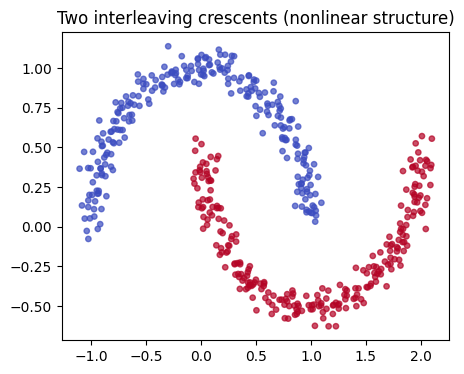

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, labels = make_moons(n_samples=500, noise=0.06, random_state=42)

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="coolwarm", alpha=0.7, s=15)
plt.title("Two interleaving crescents (nonlinear structure)")
plt.show()


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


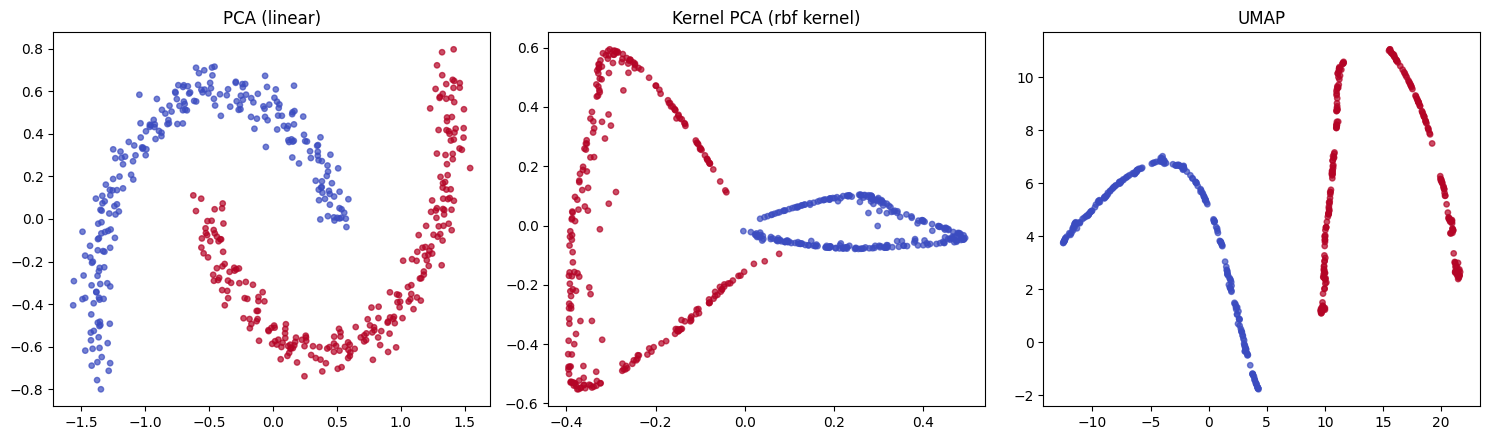

In [2]:
from sklearn.decomposition import PCA, KernelPCA
import umap

pca_result = PCA(n_components=2).fit_transform(X)
kpca_result = KernelPCA(n_components=2, kernel="rbf", gamma=10).fit_transform(X)
umap_result = umap.UMAP(n_components=2, random_state=42).fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, result, title in zip(
    axes,
    [pca_result, kpca_result, umap_result],
    ["PCA (linear)", "Kernel PCA (rbf kernel)", "UMAP"],
):
    ax.scatter(result[:, 0], result[:, 1], c=labels, cmap="coolwarm", alpha=0.7, s=15)
    ax.set_title(title)

plt.tight_layout()
plt.show()


Notice: PCA's projection still shows the two crescents tangled together -- it can only rotate/project linearly, so it cannot "unfold" curved structure. Kernel PCA and UMAP both untangle the crescents into cleanly separated groups, because both can bend and reshape the space nonlinearly before reducing it. This is the concrete version of the rule of thumb above: when structure is curved, linear methods alone won't reveal it.
